# Basic Trading Strategy: XGBoost on 15-Minute Intraday Prices

**Objective**: Train XGBoost without news data to predict 15-minute intraday continuous prices, then execute a simple long/short trading strategy based on predictions vs day-ahead auction prices.

**Strategy**:
- If predicted intraday price > day-ahead price → LONG (buy) - expecting price to rise
- If predicted intraday price < day-ahead price → SHORT (sell) - expecting price to fall


In [16]:
import pandas as pd
import numpy as np
import json
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("colorblind")


## 1. Load Data from data.json


In [17]:
# Load data from JSON file
with open('data.json', 'r') as f:
    json_data = json.load(f)

# Extract timestamps from Series 0
timestamps = json_data[0]['xAxisValues']

# Extract target variable: Series 8 - Intraday Continuous 15 minutes Average Price
target_series = json_data[8]
target_prices = target_series['data']

# Extract day-ahead reference: Series 6 - Day Ahead Auction
day_ahead_series = json_data[6]
day_ahead_prices = day_ahead_series['data']

# Extract power generation features
# Series 4: Load
load_series = json_data[4]
load_data = load_series['data']

# Series 3: Renewable generation
renewable_series = json_data[3]
renewable_data = renewable_series['data']

# Series 2: Non-Renewable generation
non_renewable_series = json_data[2]
non_renewable_data = non_renewable_series['data']

print(f"Data loaded successfully")
print(f"Timestamps: {len(timestamps)}")
print(f"Target prices: {len(target_prices)} ({sum(1 for x in target_prices if x is not None)} non-null)")
print(f"Day-ahead prices: {len(day_ahead_prices)} ({sum(1 for x in day_ahead_prices if x is not None)} non-null)")


Data loaded successfully
Timestamps: 28896
Target prices: 28896 (28704 non-null)
Day-ahead prices: 28896 (2596 non-null)


## 2. Create DataFrame and Handle Missing Values


In [18]:
# Create DataFrame with all features
df = pd.DataFrame({
    'timestamp': pd.to_datetime(timestamps, unit='ms'),
    'price_intraday': target_prices,
    'price_day_ahead': day_ahead_prices,
    'load': load_data,
    'renewable': renewable_data,
    'non_renewable': non_renewable_data
})

# Set timestamp as index
df.set_index('timestamp', inplace=True)

print(f"Initial DataFrame shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

# Check missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())

# Handle missing values using interpolation (time-based)
df = df.interpolate(method='time').ffill().bfill()

print(f"\nAfter interpolation - Missing values:")
print(df.isnull().sum())
print(f"\nFinal DataFrame shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()


Initial DataFrame shape: (28896, 5)
Date range: 2024-12-31 23:00:00 to 2025-10-28 22:45:00

Missing values per column:
price_intraday       192
price_day_ahead    26300
load                 156
renewable            157
non_renewable        157
dtype: int64

After interpolation - Missing values:
price_intraday     0
price_day_ahead    0
load               0
renewable          0
non_renewable      0
dtype: int64

Final DataFrame shape: (28896, 5)

First few rows:


,price_intraday,price_day_ahead,load,renewable,non_renewable
timestamp,,,,,
2024-12-31 23:00:00,43.46,102.6,48412.11,40865.209354,12081.397098
2024-12-31 23:15:00,26.53,102.6,47534.70,40848.249388,11718.437716
2024-12-31 23:30:00,20.47,102.6,47573.45,40641.108186,11649.278078
2024-12-31 23:45:00,46.87,102.6,47446.87,40595.907478,11735.979151
2025-01-01 00:00:00,87.24,102.6,47200.27,40791.123470,12080.185876


## 3. Feature Engineering

Create temporal, lag, and rolling window features adapted for 15-minute intervals.


In [19]:
# Temporal features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['day_of_year'] = df.index.dayofyear
df['month'] = df.index.month
df['week_of_year'] = df.index.isocalendar().week.values

# Lag features for price (96 = 24 hours in 15-min intervals, 672 = 7 days)
df['price_lag_96'] = df['price_intraday'].shift(96)
df['price_lag_672'] = df['price_intraday'].shift(672)

# Lag features for power variables
df['load_lag_96'] = df['load'].shift(96)
df['renewable_lag_96'] = df['renewable'].shift(96)
df['non_renewable_lag_96'] = df['non_renewable'].shift(96)

# Rolling window features for price (96 = 24 hours)
df['price_rolling_mean_96'] = df['price_intraday'].rolling(window=96, min_periods=1).mean()
df['price_rolling_std_96'] = df['price_intraday'].rolling(window=96, min_periods=1).std()

# Drop rows with NaN values from lag features
df = df.dropna()

print(f"Features created. Rows after dropping NaN: {len(df)}")
print(f"\nFeatures: {[col for col in df.columns]}")
df.describe()


Features created. Rows after dropping NaN: 28224

Features: ['price_intraday', 'price_day_ahead', 'load', 'renewable', 'non_renewable', 'hour', 'day_of_week', 'day_of_year', 'month', 'week_of_year', 'price_lag_96', 'price_lag_672', 'load_lag_96', 'renewable_lag_96', 'non_renewable_lag_96', 'price_rolling_mean_96', 'price_rolling_std_96']


,price_intraday,price_day_ahead,load,renewable,non_renewable,hour,day_of_week,day_of_year,month,week_of_year,price_lag_96,price_lag_672,load_lag_96,renewable_lag_96,non_renewable_lag_96,price_rolling_mean_96,price_rolling_std_96
count,28224.000000,28224.000000,28224.000000,28224.000000,28224.000000,28224.000000,28224.000000,28224.000000,28224.000000,28224.0,28224.000000,28224.000000,28224.000000,28224.000000,28224.000000,28224.000000,28224.000000
mean,88.123485,100.803834,52504.429152,30067.363565,17482.100493,11.500000,3.000000,154.458333,5.587160,22.779762,88.355605,89.037809,52489.822300,30067.007156,17510.780838,88.263301,44.432662
std,62.084108,18.801902,8949.819243,14497.382469,8259.785377,6.922309,2.000035,84.871737,2.797805,12.129442,61.911492,61.340821,8945.749683,14497.996544,8242.069106,35.466086,25.238761
min,-467.740000,-5.090000,33580.650000,6680.630754,3921.531484,0.000000,0.000000,7.000000,1.000000,2.0,-467.740000,-467.740000,33580.650000,6680.630754,3921.531484,-9.488854,0.000000
25%,63.147500,102.600000,45033.555000,17627.394952,10304.416714,5.750000,1.000000,81.000000,3.000000,12.0,63.670000,64.947500,45033.555000,17627.394952,10362.460403,67.681510,27.481859
50%,92.240000,102.600000,52599.405000,27736.773429,16196.345064,11.500000,3.000000,154.000000,6.000000,23.0,92.340000,92.815000,52575.310000,27736.773429,16265.315313,86.656146,40.892527
75%,115.860000,102.600000,59079.992500,41175.228511,23927.333026,17.250000,5.000000,228.000000,8.000000,33.0,115.862500,116.302500,59046.552500,41175.228511,23927.333026,106.840625,54.829604
max,1002.190000,508.380000,75770.650000,73654.887933,39633.187246,23.000000,6.000000,301.000000,10.000000,44.0,1002.190000,1002.190000,75770.650000,73654.887933,39633.187246,214.745000,221.291947


## 4. Train-Test Split (85/15 Chronological)


In [20]:
# Define split date (85% for training)
total_days = (df.index.max() - df.index.min()).days
split_days = int(total_days * 0.85)
split_date = df.index.min() + timedelta(days=split_days)

# Create train/test masks
train_mask = df.index < split_date
test_mask = df.index >= split_date

# Define features (exclude target and reference price)
feature_cols = [
    'price_day_ahead', 'load', 'renewable', 'non_renewable',
    'hour', 'day_of_week', 'day_of_year', 'month', 'week_of_year',
    'price_lag_96', 'price_lag_672',
    'load_lag_96', 'renewable_lag_96', 'non_renewable_lag_96',
    'price_rolling_mean_96', 'price_rolling_std_96'
]

X_train = df.loc[train_mask, feature_cols]
X_test = df.loc[test_mask, feature_cols]

y_train = df.loc[train_mask, 'price_intraday']
y_test = df.loc[test_mask, 'price_intraday']

# Also keep day-ahead prices for trading strategy
day_ahead_test = df.loc[test_mask, 'price_day_ahead']

print(f"Split date: {split_date}")
print(f"\nTraining set: {X_train.shape}")
print(f"  Date range: {X_train.index.min()} to {X_train.index.max()}")
print(f"\nTest set: {X_test.shape}")
print(f"  Date range: {X_test.index.min()} to {X_test.index.max()}")


Split date: 2025-09-13 23:00:00

Training set: (23904, 16)
  Date range: 2025-01-07 23:00:00 to 2025-09-13 22:45:00

Test set: (4320, 16)
  Date range: 2025-09-13 23:00:00 to 2025-10-28 22:45:00


## 5. Train XGBoost Model


In [21]:
print("Training XGBoost model...")
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    n_jobs=-1
)

# Train with early stopping
model.fit(
    X_train, 
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

print(f"\nModel trained successfully!")
print(f"Best iteration: {model.best_iteration}")
print(f"Best score: {model.best_score:.4f}")


Training XGBoost model...
[0]	validation_0-rmse:55.76051
[1]	validation_0-rmse:53.45758
[2]	validation_0-rmse:51.32146
[3]	validation_0-rmse:49.84461
[4]	validation_0-rmse:48.00719
[5]	validation_0-rmse:46.72273
[6]	validation_0-rmse:45.39446
[7]	validation_0-rmse:44.40982
[8]	validation_0-rmse:43.07340
[9]	validation_0-rmse:44.41243
[10]	validation_0-rmse:43.49676
[11]	validation_0-rmse:42.82927
[12]	validation_0-rmse:42.03791
[13]	validation_0-rmse:42.09046
[14]	validation_0-rmse:41.59196
[15]	validation_0-rmse:41.20153
[16]	validation_0-rmse:40.95939
[17]	validation_0-rmse:40.62679
[18]	validation_0-rmse:40.32795
[19]	validation_0-rmse:40.06454
[20]	validation_0-rmse:39.84086
[21]	validation_0-rmse:39.65127
[22]	validation_0-rmse:39.61038
[23]	validation_0-rmse:39.42043
[24]	validation_0-rmse:39.25614
[25]	validation_0-rmse:39.08063
[26]	validation_0-rmse:39.00278
[27]	validation_0-rmse:38.86334
[28]	validation_0-rmse:38.85145
[29]	validation_0-rmse:38.94573
[30]	validation_0-rmse:3

## 6. Generate Predictions and Calculate Metrics


In [22]:
# Generate predictions
y_pred = model.predict(X_test)

# Calculate prediction metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 60)
print("PREDICTION PERFORMANCE")
print("=" * 60)
print(f"MAE: {mae:.2f} €/MWh")
print(f"RMSE: {rmse:.2f} €/MWh")
print(f"R²: {r2:.4f}")
print("=" * 60)


PREDICTION PERFORMANCE
MAE: 27.78 €/MWh
RMSE: 38.85 €/MWh
R²: 0.5430


## 7. Implement Trading Strategy

Long if predicted > day-ahead (price will rise), Short if predicted < day-ahead (price will fall)


In [23]:
# Generate trading signals
# If predicted > day-ahead, go LONG (expecting price to rise)
# If predicted < day-ahead, go SHORT (expecting price to fall)
signals = (y_pred > day_ahead_test.values).astype(int)  # 1 = Long, 0 = Short

# Calculate P&L for each trade
pnl = np.where(signals == 1, 
               y_test.values - day_ahead_test.values,  # Long P&L
               day_ahead_test.values - y_test.values)   # Short P&L

# Create results DataFrame
results_df = pd.DataFrame({
    'timestamp': X_test.index,
    'actual_price': y_test.values,
    'predicted_price': y_pred,
    'day_ahead_price': day_ahead_test.values,
    'signal': signals,
    'pnl': pnl
})
results_df.set_index('timestamp', inplace=True)
results_df['signal_name'] = results_df['signal'].map({1: 'LONG', 0: 'SHORT'})

print("Trading signals generated successfully!")
print(f"\nSignal distribution:")
print(results_df['signal_name'].value_counts())
print(f"\nSample results:")
results_df.head()


Trading signals generated successfully!

Signal distribution:
signal_name
LONG     2602
SHORT    1718
Name: count, dtype: int64

Sample results:


,actual_price,predicted_price,day_ahead_price,signal,pnl,signal_name
timestamp,,,,,,
2025-09-13 23:00:00,98.47,81.390015,102.6,0,4.13,SHORT
2025-09-13 23:15:00,91.36,83.395302,102.6,0,11.24,SHORT
2025-09-13 23:30:00,95.18,82.742058,102.6,0,7.42,SHORT
2025-09-13 23:45:00,90.14,82.742058,102.6,0,12.46,SHORT
2025-09-14 00:00:00,91.90,78.370651,102.6,0,10.70,SHORT


## 8. Trading Performance Metrics


In [24]:
# Calculate cumulative P&L
results_df['cumulative_pnl'] = results_df['pnl'].cumsum()

# Trading metrics
total_pnl = results_df['pnl'].sum()
total_trades = len(results_df)
win_rate = (results_df['pnl'] > 0).sum() / total_trades * 100
avg_profit = results_df['pnl'].mean()
long_count = results_df['signal'].sum()
short_count = total_trades - long_count

# Sharpe ratio
pnl_std = results_df['pnl'].std()
sharpe_ratio = (avg_profit / pnl_std) * np.sqrt(total_trades) if pnl_std > 0 else 0

# Maximum drawdown
running_max = results_df['cumulative_pnl'].expanding().max()
drawdown = results_df['cumulative_pnl'] - running_max
max_drawdown = drawdown.min()

# Calculate cumulative returns
cumulative_return = total_pnl / day_ahead_test.sum() * 100

print("=" * 70)
print("TRADING PERFORMANCE SUMMARY")
print("=" * 70)
print(f"Total P&L: {total_pnl:.2f} €/MWh")
print(f"Total trades: {total_trades}")
print(f"Long positions: {long_count} ({long_count/total_trades*100:.1f}%)")
print(f"Short positions: {short_count} ({short_count/total_trades*100:.1f}%)")
print(f"Win rate: {win_rate:.2f}%")
print(f"Average profit per trade: {avg_profit:.4f} €/MWh")
print(f"Sharpe ratio: {sharpe_ratio:.4f}")
print(f"Maximum drawdown: {max_drawdown:.2f} €/MWh")
print(f"Cumulative return: {cumulative_return:.4f}%")
print("=" * 70)


TRADING PERFORMANCE SUMMARY
Total P&L: 81686.44 €/MWh
Total trades: 4320
Long positions: 2602 (60.2%)
Short positions: 1718 (39.8%)
Win rate: 72.15%
Average profit per trade: 18.9089 €/MWh
Sharpe ratio: 33.9780
Maximum drawdown: -4633.69 €/MWh
Cumulative return: 20.8099%


## 9. Visualizations


### 9.1: Actual vs Predicted Prices (Sample Week)


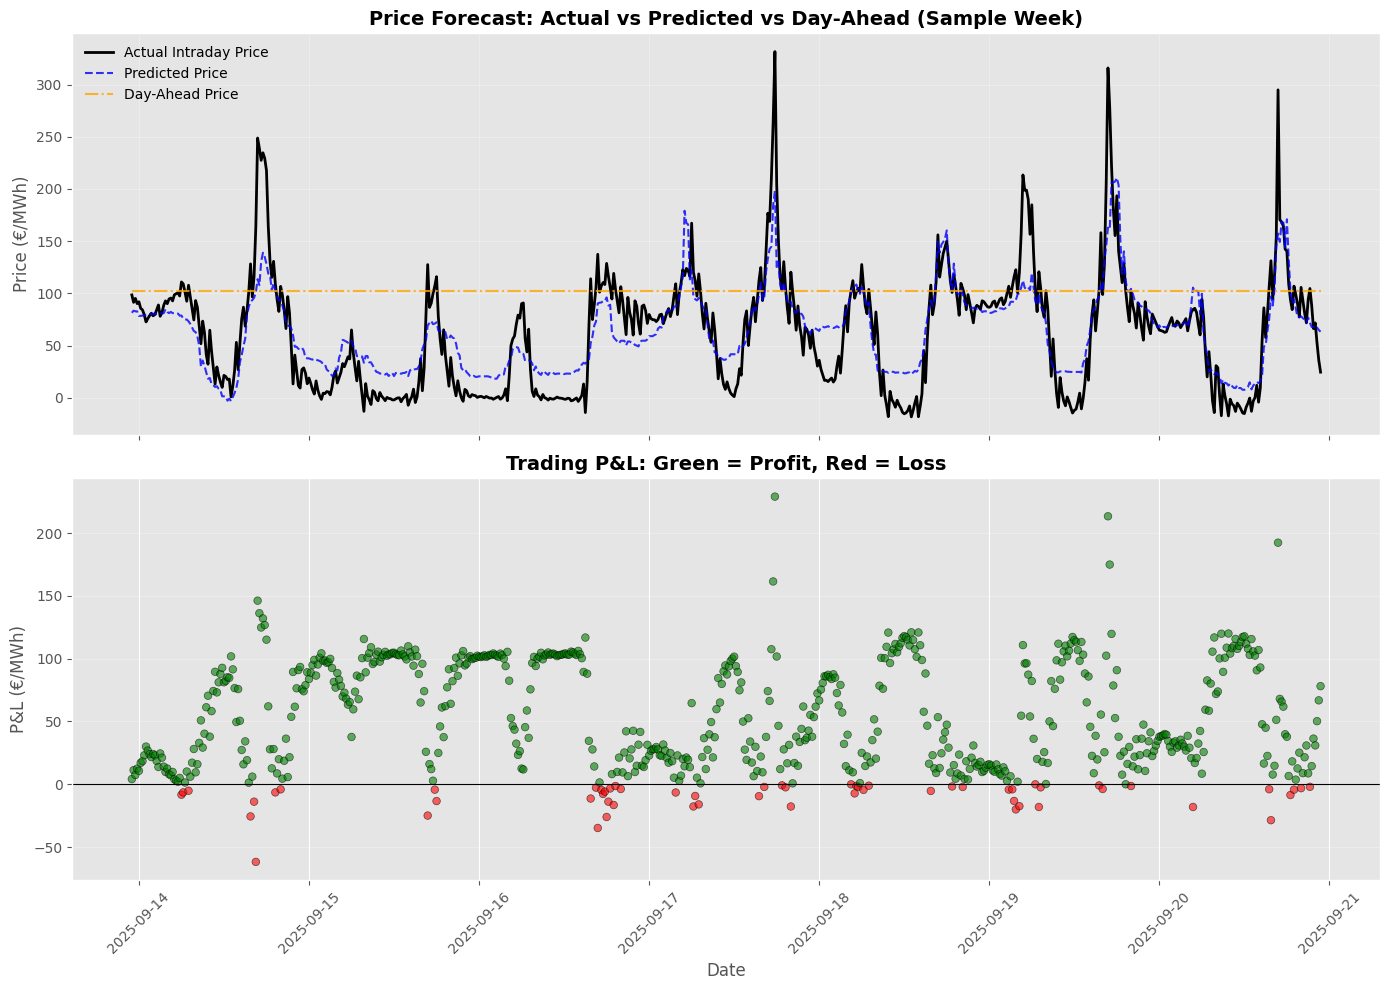

Sample week error statistics:
  MAE: 21.65 €/MWh
  Sample period P&L: 36103.38 €/MWh
  Profitable trades: 613/672


In [25]:
# Select one week from test set for visualization
sample_start = results_df.index.min()
sample_end = sample_start + timedelta(days=7)
sample_mask = (results_df.index >= sample_start) & (results_df.index < sample_end)
sample_df = results_df[sample_mask]

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top plot: Actual vs Predicted vs Day-Ahead prices
axes[0].plot(sample_df.index, sample_df['actual_price'], 
             label='Actual Intraday Price', linewidth=2, color='black')
axes[0].plot(sample_df.index, sample_df['predicted_price'], 
             label='Predicted Price', linewidth=1.5, linestyle='--', alpha=0.8, color='blue')
axes[0].plot(sample_df.index, sample_df['day_ahead_price'], 
             label='Day-Ahead Price', linewidth=1.5, linestyle='-.', alpha=0.8, color='orange')

axes[0].set_ylabel('Price (€/MWh)', fontsize=12)
axes[0].set_title('Price Forecast: Actual vs Predicted vs Day-Ahead (Sample Week)', fontsize=14, fontweight='bold')
axes[0].legend(frameon=False, loc='best')
axes[0].grid(True, alpha=0.3)

# Bottom plot: Trading signals and P&L
colors = ['green' if x > 0 else 'red' for x in sample_df['pnl']]
axes[1].scatter(sample_df.index, sample_df['pnl'], 
                c=colors, alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('P&L (€/MWh)', fontsize=12)
axes[1].set_title('Trading P&L: Green = Profit, Red = Loss', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Sample week error statistics:")
sample_mae = mean_absolute_error(sample_df['actual_price'], sample_df['predicted_price'])
print(f"  MAE: {sample_mae:.2f} €/MWh")
print(f"  Sample period P&L: {sample_df['pnl'].sum():.2f} €/MWh")
print(f"  Profitable trades: {(sample_df['pnl'] > 0).sum()}/{len(sample_df)}")


### 9.2: Cumulative P&L Over Test Period


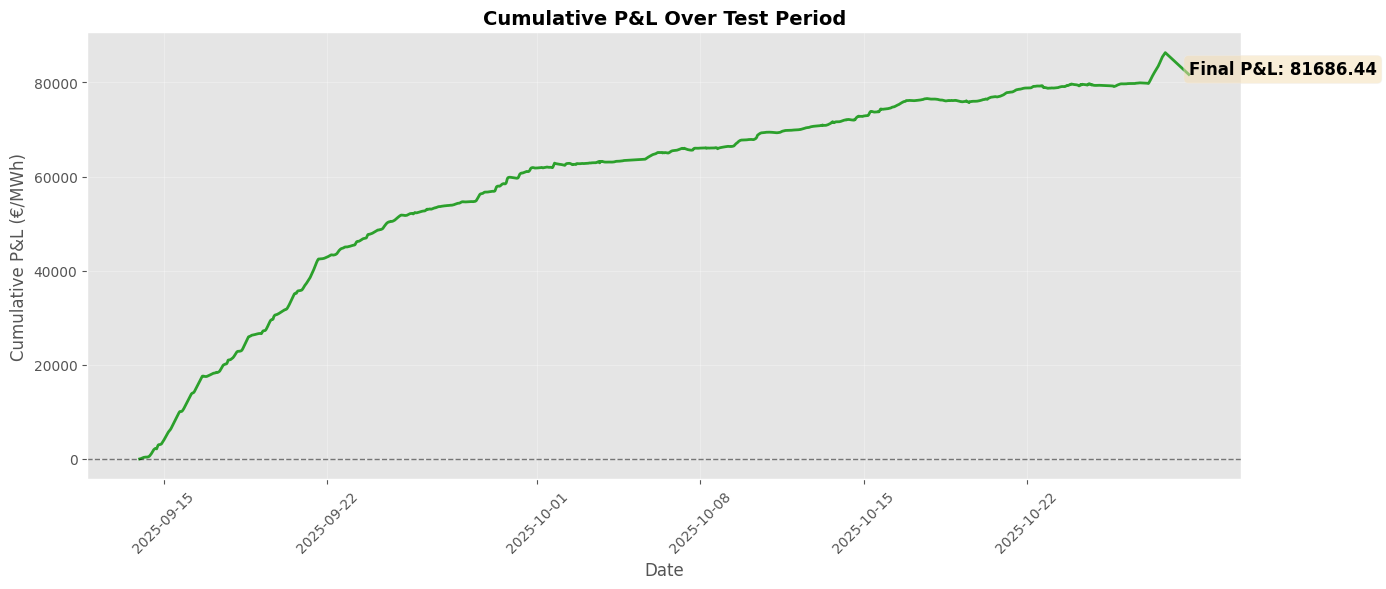

Cumulative P&L: 81686.44 €/MWh


In [26]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(results_df.index, results_df['cumulative_pnl'], linewidth=2, color='#2ca02c')

# Add zero line
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative P&L (€/MWh)', fontsize=12)
ax.set_title('Cumulative P&L Over Test Period', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Annotate final P&L
final_pnl = results_df['cumulative_pnl'].iloc[-1]
ax.text(results_df.index[-1], final_pnl, 
        f'Final P&L: {final_pnl:.2f}', 
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Cumulative P&L: {total_pnl:.2f} €/MWh")


### 9.3: Trade Distribution and P&L Analysis


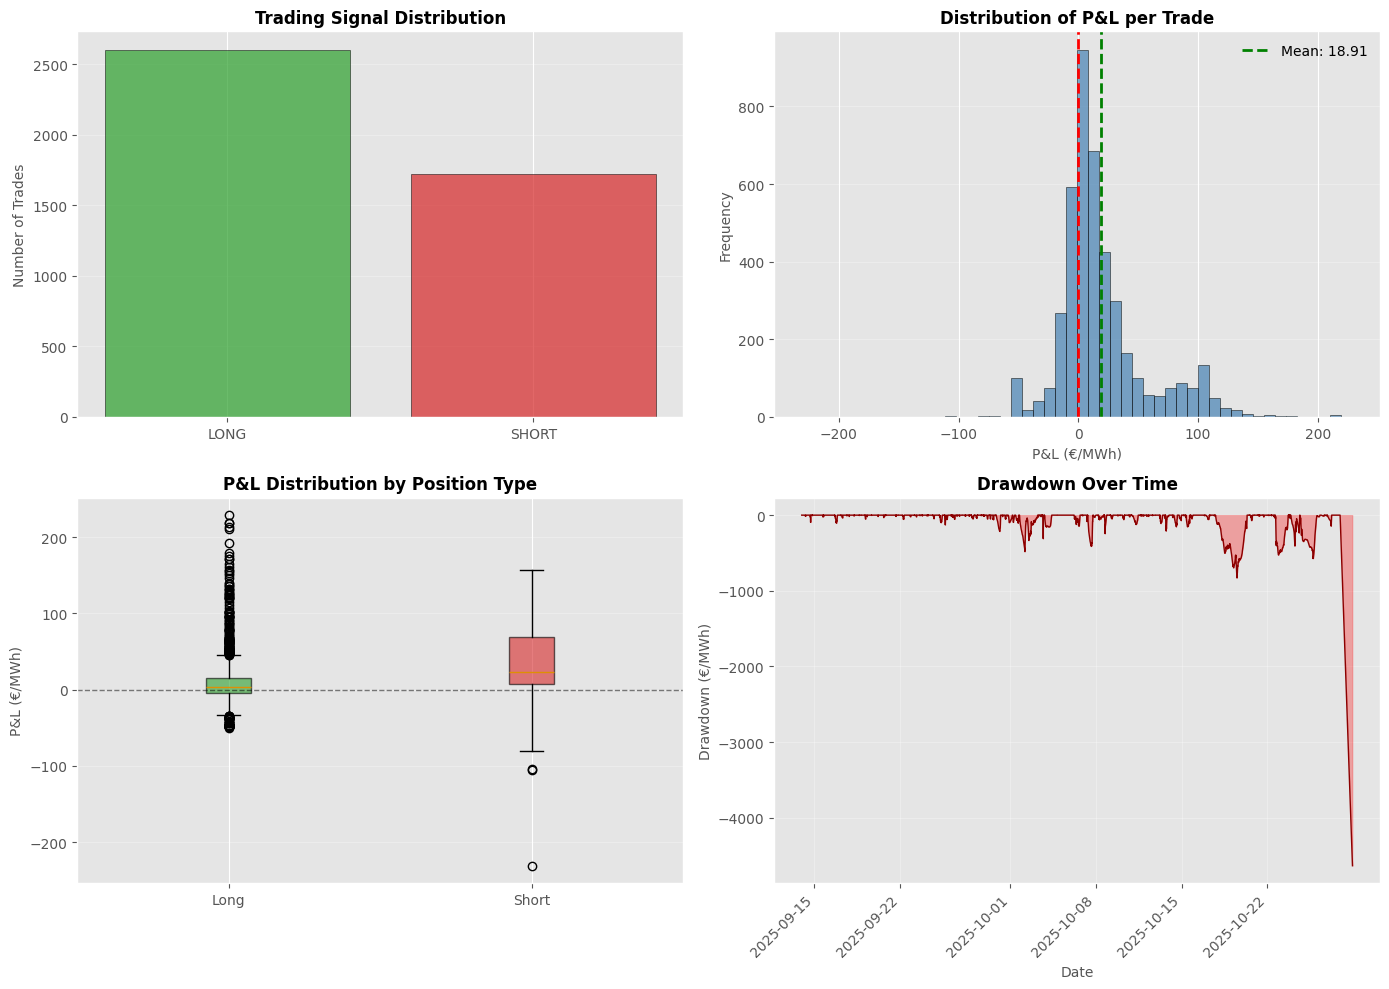


Long vs Short Performance:
  Long average P&L: 7.4672 €/MWh (std: 27.6917)
  Short average P&L: 36.2380 €/MWh (std: 41.2901)
  Long win rate: 63.57%
  Short win rate: 85.16%


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Signal distribution (Long vs Short)
signal_counts = results_df['signal_name'].value_counts()
colors_signal = ['#2ca02c', '#d62728']
axes[0, 0].bar(signal_counts.index, signal_counts.values, color=colors_signal, alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('Number of Trades', fontsize=10)
axes[0, 0].set_title('Trading Signal Distribution', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Top-right: P&L histogram
axes[0, 1].hist(results_df['pnl'], bins=50, alpha=0.7, edgecolor='black', color='steelblue')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(x=results_df['pnl'].mean(), color='green', linestyle='--', 
                   linewidth=2, label=f'Mean: {results_df["pnl"].mean():.2f}')
axes[0, 1].set_xlabel('P&L (€/MWh)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Distribution of P&L per Trade', fontsize=12, fontweight='bold')
axes[0, 1].legend(frameon=False)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Bottom-left: Long vs Short P&L comparison
long_pnl = results_df[results_df['signal'] == 1]['pnl']
short_pnl = results_df[results_df['signal'] == 0]['pnl']

box_data = [long_pnl, short_pnl]
bp = axes[1, 0].boxplot(box_data, labels=['Long', 'Short'], patch_artist=True)
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].set_ylabel('P&L (€/MWh)', fontsize=10)
axes[1, 0].set_title('P&L Distribution by Position Type', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Color the boxes
for patch, color in zip(bp['boxes'], ['#2ca02c', '#d62728']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Bottom-right: Drawdown
axes[1, 1].fill_between(results_df.index, drawdown, 0, alpha=0.3, color='red')
axes[1, 1].plot(results_df.index, drawdown, linewidth=1, color='darkred')
axes[1, 1].set_xlabel('Date', fontsize=10)
axes[1, 1].set_ylabel('Drawdown (€/MWh)', fontsize=10)
axes[1, 1].set_title('Drawdown Over Time', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nLong vs Short Performance:")
print(f"  Long average P&L: {long_pnl.mean():.4f} €/MWh (std: {long_pnl.std():.4f})")
print(f"  Short average P&L: {short_pnl.mean():.4f} €/MWh (std: {short_pnl.std():.4f})")
print(f"  Long win rate: {(long_pnl > 0).sum()/len(long_pnl)*100:.2f}%")
print(f"  Short win rate: {(short_pnl > 0).sum()/len(short_pnl)*100:.2f}%")


### 9.4: Scatter Plot - Predicted vs Actual Prices


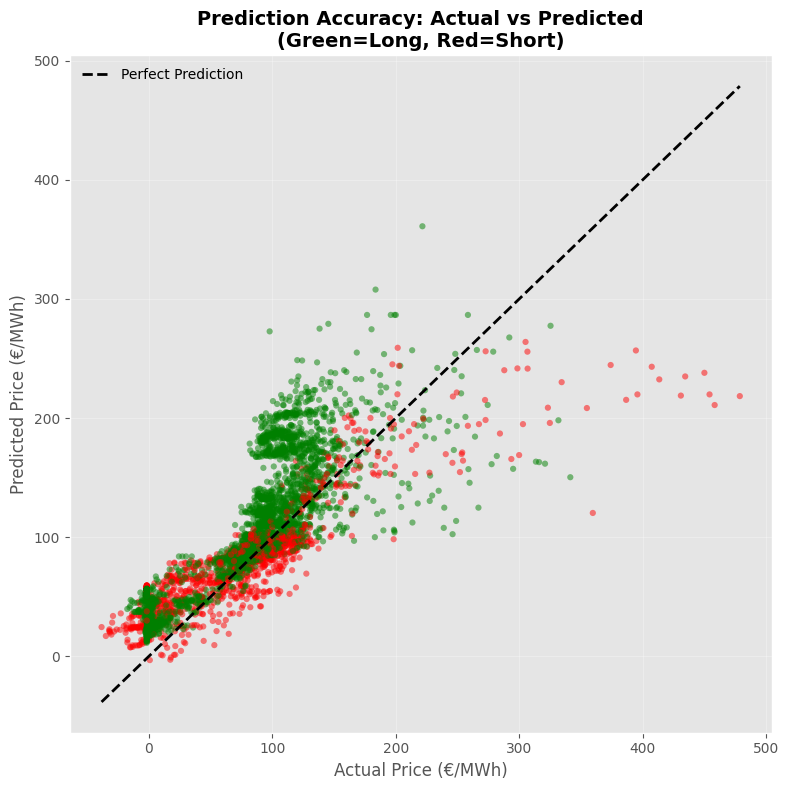

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))

# Color code points by signal type
colors_plot = ['green' if s == 1 else 'red' for s in results_df['signal']]
ax.scatter(results_df['actual_price'], results_df['predicted_price'], 
           c=colors_plot, alpha=0.5, s=20, edgecolors='none')

# Perfect prediction line
min_price = min(results_df['actual_price'].min(), results_df['predicted_price'].min())
max_price = max(results_df['actual_price'].max(), results_df['predicted_price'].max())
ax.plot([min_price, max_price], [min_price, max_price], 
        'k--', lw=2, label='Perfect Prediction')

ax.set_xlabel('Actual Price (€/MWh)', fontsize=12)
ax.set_ylabel('Predicted Price (€/MWh)', fontsize=12)
ax.set_title('Prediction Accuracy: Actual vs Predicted\n(Green=Long, Red=Short)', fontsize=14, fontweight='bold')
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 9.5: Day-Ahead vs Intraday Price Spread Analysis


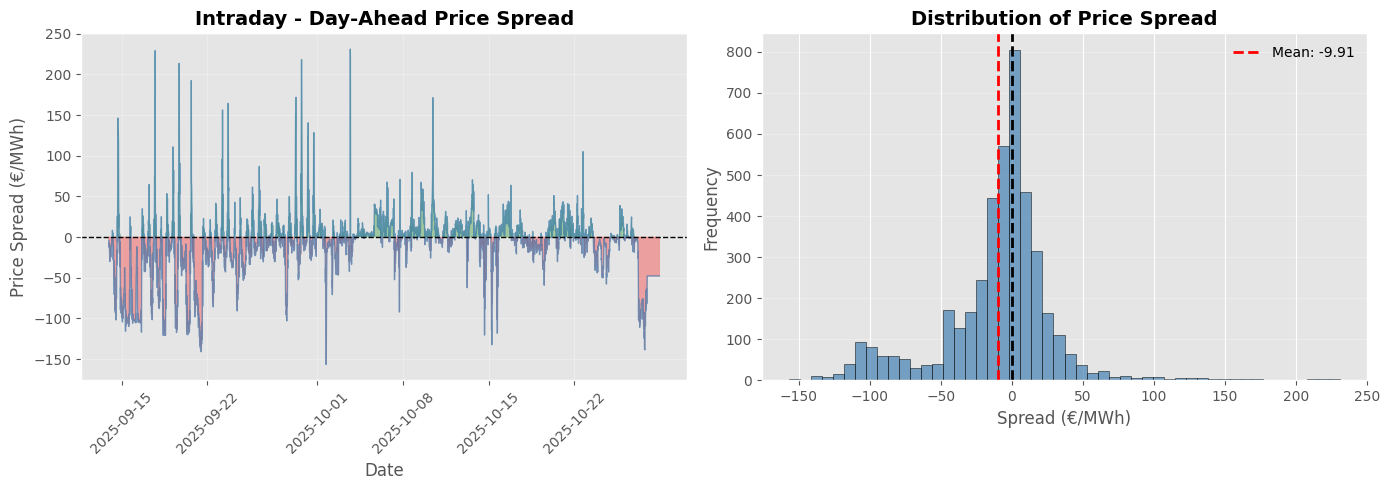

Spread statistics:
  Mean spread: -9.9137 €/MWh
  Std spread: 39.9651 €/MWh
  Min spread: -156.59 €/MWh
  Max spread: 231.04 €/MWh


In [29]:
# Calculate spread
spread = results_df['actual_price'] - results_df['day_ahead_price']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Spread over time
axes[0].plot(results_df.index, spread, linewidth=1, alpha=0.7, color='steelblue')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].fill_between(results_df.index, 0, spread, alpha=0.3, 
                     where=(spread >= 0), color='green')
axes[0].fill_between(results_df.index, 0, spread, alpha=0.3, 
                     where=(spread < 0), color='red')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Price Spread (€/MWh)', fontsize=12)
axes[0].set_title('Intraday - Day-Ahead Price Spread', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Right: Spread histogram
axes[1].hist(spread, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=2)
axes[1].axvline(x=spread.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {spread.mean():.2f}')
axes[1].set_xlabel('Spread (€/MWh)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Price Spread', fontsize=14, fontweight='bold')
axes[1].legend(frameon=False)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Spread statistics:")
print(f"  Mean spread: {spread.mean():.4f} €/MWh")
print(f"  Std spread: {spread.std():.4f} €/MWh")
print(f"  Min spread: {spread.min():.2f} €/MWh")
print(f"  Max spread: {spread.max():.2f} €/MWh")


## 10. Summary


In [30]:
print("=" * 80)
print("COMPREHENSIVE SUMMARY")
print("=" * 80)
print(f"\nModel Performance:")
print(f"  MAE: {mae:.2f} €/MWh")
print(f"  RMSE: {rmse:.2f} €/MWh")
print(f"  R²: {r2:.4f}")
print(f"\nTrading Performance:")
print(f"  Total P&L: {total_pnl:.2f} €/MWh")
print(f"  Win rate: {win_rate:.2f}%")
print(f"  Sharpe ratio: {sharpe_ratio:.4f}")
print(f"  Maximum drawdown: {max_drawdown:.2f} €/MWh")
print(f"  Long positions: {long_count} ({long_count/total_trades*100:.1f}%)")
print(f"  Short positions: {short_count} ({short_count/total_trades*100:.1f}%)")
print(f"\n  Long avg P&L: {long_pnl.mean():.4f} €/MWh")
print(f"  Short avg P&L: {short_pnl.mean():.4f} €/MWh")
print("=" * 80)


COMPREHENSIVE SUMMARY

Model Performance:
  MAE: 27.78 €/MWh
  RMSE: 38.85 €/MWh
  R²: 0.5430

Trading Performance:
  Total P&L: 81686.44 €/MWh
  Win rate: 72.15%
  Sharpe ratio: 33.9780
  Maximum drawdown: -4633.69 €/MWh
  Long positions: 2602 (60.2%)
  Short positions: 1718 (39.8%)

  Long avg P&L: 7.4672 €/MWh
  Short avg P&L: 36.2380 €/MWh
